# Line Search Algorithms

Line search algorithms take the following form:

1. Pick an initial design point $x$, a stopping tolerance $\epsilon$ and set $k = 1$
2. If $||\nabla f(x)||_{2} \le \epsilon$ exit
3. Choose a descent direction $p$ such that $p^{T} \nabla f(x) < 0$
4. Find a step length $\alpha$ for $\phi(\alpha) = f(x + \alpha p)$ satisfying line search criteria
5. Set $x \leftarrow x + \alpha p$ and $k \leftarrow k+1$ and go to step 2

## Steepest descent method

Why not head directly downhill? The direction in which the function $f(x)$ increases most rapidly is $\nabla f(x)$. Therefore, why not select $p = - \nabla f(x)$ as the search direction? This method is called *the steepest descent method*. This algorithm can be written as follows:

1. Pick an initial design point $x$, a stopping tolerance $\epsilon$ and set $k = 1$
2. If $||\nabla f(x)||_{2} \le \epsilon$ exit
3. Set $p = - \nabla f(x)$
4. Find a step length $\alpha$ for $\phi(\alpha) = f(x + \alpha p)$ satisfying line search criteria
5. Set $x \leftarrow x + \alpha p$ and $k \leftarrow k+1$ and go to step 2

Unfortunately, the steepest descent method can perform very poorly in practice.

### Steepest descent method for quadratic functions

To observe and analyze the behavior of the steepest descent method, we'll look at how the algorithm performs on quadratic functions.
The objective function will take the form

\begin{equation*}
f(x) = \frac{1}{2} x^{T} A x + b^{T} x
\end{equation*}

where we will assume that $A$ is positive definite so that $f(x)$ has a unique minimizer.
Furthermore, the gradient will be

\begin{equation*}
\nabla f(x) = A x + b
\end{equation*}

and we'll perform an exact line search for $\alpha$. The exact line search step length with be

\begin{equation*}
\alpha = - \dfrac{p^{T} \nabla f(x)}{p^{T} A p} = \dfrac{p^{T}p}{p^{T} A p}
\end{equation*}

Note that it will not be possible to perform an exact line search for general functions.
With these specifics, the steepest descent algorithm is

1. Pick an initial design point $x$, a stopping tolerance $\epsilon$ and set $k = 1$
2. If $||Ax + b||_{2} \le \epsilon$ exit
3. Set $p = - (Ax + b)$
4. Compute $\alpha = - \dfrac{p^{T} \nabla f}{p^{T} A p} = \dfrac{p^{T}p}{p^{T} A p}$
5. Set $x \leftarrow x + \alpha p$ and $k \leftarrow k+1$ and go to step 2

#### Examples

Consider the quadratic functions with the following data:

\begin{equation*}
A = \begin{bmatrix} 2 & 0\\ 0 & 2 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -1\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are
\begin{equation*}
\lambda_1 = \lambda_2 = 2
\end{equation*}

\begin{equation*}
A = \begin{bmatrix} 2 & 1\\ 1 & 2 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -1\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are
\begin{equation*}
\lambda_1 = 1 \qquad \lambda_2 = 3
\end{equation*}

\begin{equation*}
A = \begin{bmatrix} 10 & 0.1\\ 0.1 & 0.25 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -4\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are about
\begin{equation*}
\lambda_1 = 0.24 \qquad \lambda_2 = 10
\end{equation*}

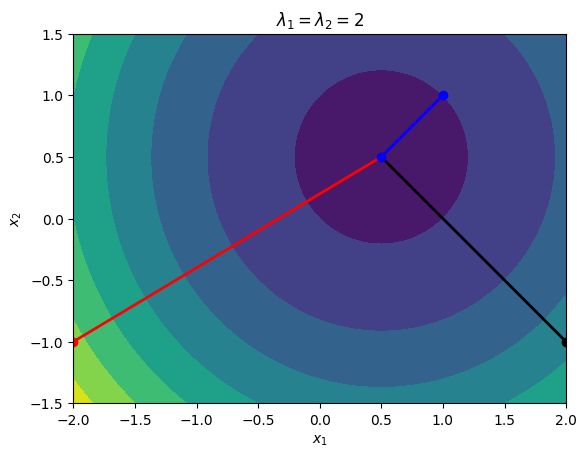

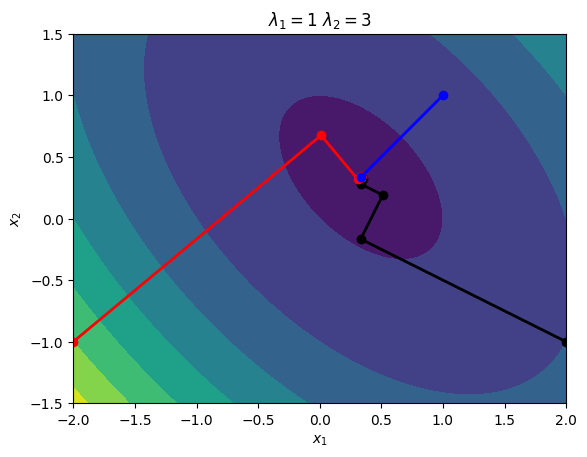

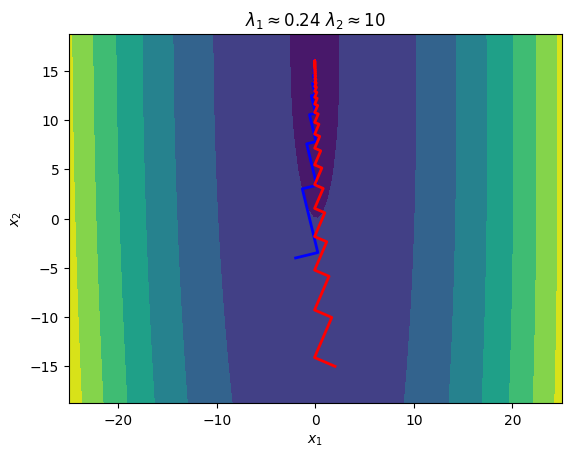

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def steepest_descent_quadratic(x, A, b, n=10, eps=1e-12):
    """
    Perform n iterations of the steepest descent method for a 
    quadratic function
    """
    
    xvals = []
    
    # Compute the steepest descent direction
    for i in range(n):
        grad = np.dot(A, x) + b
        p = -grad
        
        # Store a copy of the x values
        xvals.append(np.array(x))
        
        if np.sqrt(np.dot(grad, grad)) < eps:
            break

        alpha = -np.dot(grad, p)/np.dot(p, np.dot(A, p))
        x = x + alpha*p
    
    return np.array(xvals)

def plot_quadratic_contour(A, b, xdim=2):
    # Generate plot
    n = 100 
    x = np.linspace(-xdim, xdim, n)
    y = np.linspace(-0.75*xdim, 0.75*xdim, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array([X[i,j], Y[i,j]])
            f[i, j] = 0.5*np.dot(x, np.dot(A, x)) + np.dot(x, b)

    fig, ax = plt.subplots(1, 1)
    ax.contourf(X, Y, f)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    ax.set_aspect('equal', 'box')
    
    return

A = np.array([[2.0, 0.0], [0.0, 2.0]])
b = np.array([-1.0, -1.0])
plot_quadratic_contour(A, b)

x0 = np.array([2.0, -1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'k-o', linewidth=2)

x0 = np.array([-2.0, -1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'r-o', linewidth=2)

x0 = np.array([1.0, 1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'b-o', linewidth=2)
plt.title('$\lambda_{1} = \lambda_{2} = 2$')

A = np.array([[2.0, 1.0], [1.0, 2.0]])
b = np.array([-1.0, -1.0])
plot_quadratic_contour(A, b)

x0 = np.array([2.0, -1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'k-o', linewidth=2)

x0 = np.array([-2.0, -1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'r-o', linewidth=2)

x0 = np.array([1.0, 1.0])
xvals = steepest_descent_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'b-o', linewidth=2)
plt.title('$\lambda_{1} = 1$ $\lambda_{2} = 3$')

A = np.array([[10.0, 0.1], [0.1, 0.25]])
b = np.array([-1.0, -4.0])
plot_quadratic_contour(A, b, xdim=25)

x0 = np.array([-2.0, -4.0])
xvals = steepest_descent_quadratic(x0, A, b, n=100)
plt.plot(xvals[:,0], xvals[:,1], 'b-', linewidth=2)

x0 = np.array([2.0, -15.0])
xvals = steepest_descent_quadratic(x0, A, b, n=100)
plt.plot(xvals[:,0], xvals[:,1], 'r-', linewidth=2)

plt.title('$\lambda_{1} \\approx 0.24$ $\lambda_{2} \\approx 10$')
plt.show()

### Subsequent Search Directions are Orthogonal

If you look at these contours, the subsequent line search directions are always perpendicular. 
If $x$ is one iteration, then we have the search direction $p = -(Ax + b)$ and the new point will be

\begin{equation*}
y = x + \alpha p
\end{equation*}

The new search direction from the updated point $y$ will be $p_{y} = -(Ay + b)$.
The dot product of the subsequent search directions is

\begin{equation*}
\begin{aligned}
p_{y}^{T}p &= (Ay + b)^{T}(Ax + b) \\
&= (Ax + b + \alpha A p)^{T}(Ax + b)\\
&= \left(Ax + b - \dfrac{p^{T}p}{p^{T}Ap}A(Ax + b)\right)^{T}(Ax + b) \\
&= \left(Ax + b - \dfrac{(Ax + b)^{T} (Ax + b)}{(Ax + b)^{T}A(Ax + b)}A(Ax + b)\right)^{T}(Ax + b) \\
&= (Ax + b)^{T} (Ax + b) - \dfrac{(Ax + b)^{T}(Ax + b)}{(Ax + b)^{T}A(Ax + b)} (Ax + b)^{T}A(Ax + b) \\
&= 0
\end{aligned}
\end{equation*}

The two search directions are orthogonal.

### Analysis of the Steepest Descent Algorithm for Quadratic Functions

To analyze the performance of the algorithm more carefully for quadratic functions, define the error at the $k$-th iteration, $e_{k}$ as the difference between the current solution estimate $x$ and the exact solution, $x^* = -A^{-1}b$.
The error is

\begin{equation*}
e_{k} = x - x^{*} = x + A^{-1} b.
\end{equation*}

With this definition, the gradient at the $k$-th iteration is
\begin{equation*}
\nabla f(x) = A x + b = A x - A x^{*} = A(x - x^{*}) = A e_{k}  
\end{equation*}

The error at iteration $k+1$ can be determined based on the error at iteration $k$ as follows:
  
\begin{equation*}
\begin{aligned}
x &\leftarrow x + \alpha p \\
x - x^{*} &\leftarrow x - x^{*} - \alpha A e_{k} \\
e_{k+1} &= e_{k} - \alpha A e_{k}
\end{aligned}
\end{equation*}

In general, we can express the error, $e_{k}$, in terms of the eigenvectors as follows

\begin{equation*}
e_{k} = Q \xi
\end{equation*} 

Instead of looking at the error in the $\ell_{2}$ norm, we'll use the $A$-norm, where

\begin{equation*}
||e||_{A} = \sqrt{e^{T}A e}
\end{equation*}

The error in the A-norm between iterations $k$ and $k+1$ can be written as follows
  
\begin{equation*}
||e_{k+1}||_{A} = \omega ||e_{k}||_{A}
\end{equation*}

If $\omega < 1$ then the steepest descent method will converge!
The exact value of $\omega$ depends on the error components in the eigenvector space.
\begin{equation*}
\omega^{2} = 1 - \frac{(\xi^{T} \Lambda^2 \xi)^{2}}{(\xi^{T} \Lambda^3 \xi)(\xi^{T} \Lambda \xi)}
\end{equation*} 

But to obtain this, we would need to know $\xi$.
Instead, we can obtain a worst case upper bound on $\omega$.
The upper bound for $\omega$ depends the ratio of the largest to the smallest eigenvalues.
The condition number of a symmetric matrix is usually defined as

\begin{equation*}
\kappa(A) = \frac{\lambda_{\max}}{\lambda_{\min}}
\end{equation*}

$\kappa(A)$ is called the condition number of the matrix $A$ and it can be shown that

\begin{equation*}
||e_{k+1}||_{A} \le \left( \frac{\kappa -1}{\kappa + 1}\right) ||e_{k}||_{A}
\end{equation*}

As a result, the following condition holds

\begin{equation*}
||e_{k+1}||_{A} \le \left(\frac{\kappa -1}{\kappa + 1}\right)^{k} ||e_{1}||_{A}
\end{equation*}

### Steepest Descent Algorithm For General Nonlinear Functions

In general, we can perform the steepest descent method with either a backtracking method or with the strong Wolfe condition line search methods described in the previous section.

1. Pick an initial design point $x$, a stopping tolerance $\epsilon$, and line search constants $c_{1}$ and $c_{2}$ and set $k = 1$
2. If $||\nabla f(x)||_{2} \le \epsilon$ exit
3. Set $p = - \nabla f(x)$
4. Find a step length $\alpha$ for $\phi(\alpha) = f(x + \alpha p)$ satisfying the strong Wolfe conditions
5. Set $x \leftarrow x + \alpha p$ and $k \leftarrow k+1$ and go to step 2

### Inexact Line Searches and the Steepest Descent Algorithm

When an inexact line search is used the directions are only approximately perpendicular for an inexact line search
If we have a line search that satisfies the strong Wolfe conditions then the curvature condition, $|\phi'(\alpha)| \le c_{2} |\phi'(0)|$ implies that

\begin{equation*}
|p_{k}^{T} \nabla f(x + \alpha p)| \le c_{2} |p^{T} \nabla f(x)| = c_{2} ||\nabla f||_{2}^{2}
\end{equation*}

As a result, the search directions will be nearly orthogonal as $c_{2}$ decreases.

Steepest descent failed after 3000 iterations

x =  [0.99982909 0.99965793]
grad(x) =  [-2.30968995e-04 -5.54359076e-05]


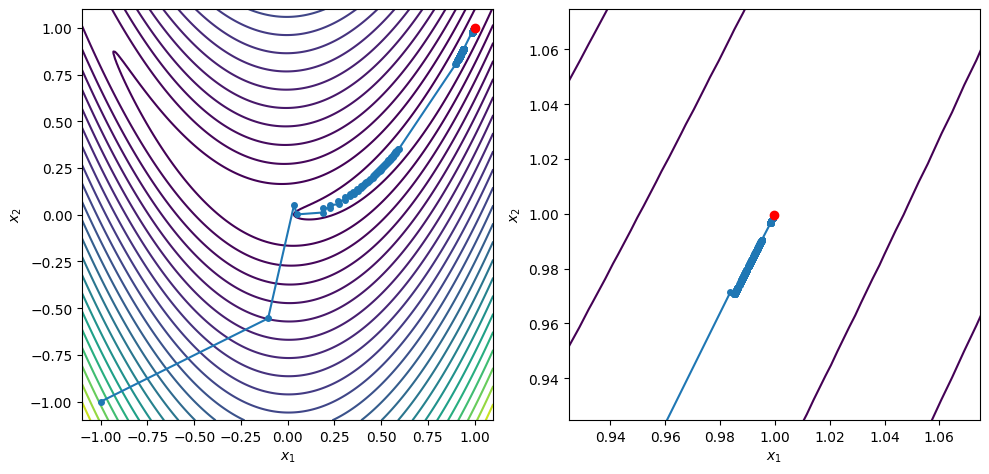

In [2]:
import numpy as np
import matplotlib.pylab as plt
from line_search_library import *

def steepest_descent(x0, func, grad_func, 
                     c1=1e-3, c2=0.9, eps=1e-6, 
                     max_iters=2500, line_search_type='strong Wolfe'):
    """
    Solve an unconstrained optimization problem using the steepest descent method.
    
    input:
    x0:         the starting point
    func:       a function pointer to f(x)
    grad_func:  a function pointer to the gradient of f(x) 
    c1:         sufficient decrease parameter
    c2:         curvature condition parameter
    eps:        stopping tolerance such that ||grad f(x)|| < eps
    max_iters:  maximum number of iterations before we give up
    """
    # Make sure we are using a np array
    x = np.array(x0)
    xvals = []
    
    for i in range(max_iters):
        grad = grad_func(x)
        xvals.append(np.array(x))
        
        # Check the norm of the gradient
        if np.sqrt(np.dot(grad, grad)) < eps:
            print('Steepest descent found first-order point in %d iterations\n'%(i))
            return x, np.array(xvals)
        
        pk = -grad/np.sqrt(np.dot(grad, grad))
        
        if line_search_type == 'strong Wolfe':
            alpha = strong_wolfe(func, grad_func, x, pk, c1=c1, c2=c2)
        else:
            alpha = backtrack(func, grad_func, x, pk, c1=c1)
        x += alpha*pk
    
    print('Steepest descent failed after %d iterations\n'%(max_iters))
    return x, np.array(xvals)

def contour_plot_function(func, xvals, xstar,
                          n=250, xlow=-1.1, xhigh=1.1,
                          ylow=-1.1, yhigh=1.1):
    """Create a contour plot of the function"""
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            f[i, j] = func([X[i, j], Y[i, j]])

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    levels = np.min(f) + (np.max(f) - np.min(f))*np.linspace(0, 1.0, 25)**2
    ax[0].contour(X, Y, f, levels=levels)
    ax[0].set_aspect('equal', 'box')

    ax[1].contour(X, Y, f, levels=levels)
    ax[1].set_aspect('equal', 'box')

    ax[0].plot(xvals[:,0], xvals[:,1], marker='o', markersize=4)
    ax[0].plot(xstar[0], xstar[1], 'ro')
    ax[1].plot(xvals[:,0], xvals[:,1], marker='o', markersize=4)
    ax[1].plot(xstar[0], xstar[1], 'ro')

    ax[0].set_xlim(-1.1, 1.1)
    ax[0].set_ylim(-1.1, 1.1)
    ax[0].set_xlabel('$x_1$')
    ax[0].set_ylabel('$x_2$')
    
    ax[1].set_xlim(xstar[0] - 0.075, xstar[0] + 0.075)
    ax[1].set_ylim(xstar[1] - 0.075, xstar[1] + 0.075)
    ax[1].set_xlabel('$x_1$')
    ax[1].set_ylabel('$x_2$')

    fig.tight_layout()    
    
    return

def rosen(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosen_grad(x):
    return np.array([-2*(1 - x[0]) - 400*(x[1] - x[0]**2)*x[0], 
                      200*(x[1] - x[0]**2) ])

# Perform a backtracking line search
x0 = [-1.0, -1.0]
xstar, xvals = steepest_descent(x0, rosen, rosen_grad, c2=0.1, max_iters=3000)

# Create a contour plot
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()

## Conjugate Gradient Method

The problem with the steepest descent direction is that we search in essentially the same direction at multiple iterations.
As a result, the solution can take many iterations to find when the condition number $\kappa(A)$ is large.

The idea behind the conjugate gradient method is to modify the steepest descent direction to improve its performance. 

The modified search direction is:

\begin{equation*}
p = - \nabla f(x) + \beta p_{\text{prev}} 
\end{equation*}

The value $\beta$ is selected to ensure that the directions satisfy a conjugacy property

* For Fletcher--Reeves, $\beta = ||\nabla f(x)||_{2}^{2}/||\nabla f(x_{\text{prev}})||_{2}^{2}$
* There are different formula for other nonlinear variants of the conjugate gradient method

The Fletcher--Reeves conjugate gradient algorithm is

1. Pick an initial design point $x$, a stopping tolerance $\epsilon$ and set $k = 1$ and $p = 0$
2. If $||\nabla f(x)||_{2} \le \epsilon$ exit
3. If $k == 1$ set $p = - \nabla f(x)$
4. Else set $p = - \nabla f(x) + \beta p_{\text{prev}}$
5. Set $p_{\text{prev}} \leftarrow p$
6. If $p^{T}\nabla f\ge 0$ set $p = -\nabla f(x)$ and $p_{\text{prev}} = p$
7. Find a step length $\alpha$ for $\phi(\alpha) = f(x + \alpha p)$ satisfying line search criteria
8. Set $x \leftarrow x + \alpha p$ and $k \leftarrow k+1$ and go to step 2

Note that we have to perform a test at step 6 to see if we actually have a descent direction.
This is due to the inexact line searches.
Using a strong Wolfe condition line search with $c_{2} < 1/2$ can guarantee a descent direction and avoid having to reject search directions.

### Conjugate Gradient Method for Quadratic Functions

As in the case of the steepest descent method, the conjugate gradient method takes a special form for quadratic functions

\begin{equation*}
f(x) = \frac{1}{2}x^{T}Ax + b^{T}x
\end{equation*}

In this version of the algorithm, we introduce the vector $g$ which is the gradient of the quadratic function at the current iteration

\begin{equation*}
g = \nabla f(x) = Ax + b
\end{equation*}

At the next iteration of the algorithm, after the step $x + \alpha p$, the new gradient will be

\begin{equation*}
g = \nabla f(x + \alpha p) = A(x + \alpha p) + b
\end{equation*}

As a result, the update for the gradient takes the form

\begin{equation*}
g \leftarrow g + \alpha A p
\end{equation*}

The line search can again be performed exactly and the exact step length is

\begin{equation*}
\alpha = - \dfrac{p^{T}(Ax + b)}{p^{T}Ap} = - \dfrac{p^{T}g}{p^{T}Ap} > 0
\end{equation*}

where $\alpha > 0$ since we have a descent direction $g^{T} p < 0$. To avoid repeated matrix-vector multiplications, we can reduce the computational cost by introducing the vector $t$ defined as

\begin{equation*}
t = Ap
\end{equation*}

As a result we can simplify so that $\alpha = - \dfrac{p^{T}g}{p^{T} t}$ and the update for the gradient can be computed as $g \leftarrow g + \alpha t$.
In addition, we compute the square of the norm of the gradient vector as $\eta$ and keep its value from the previous iteration as $\gamma$. As a result $\beta = \dfrac{\eta}{\gamma}$
With these definitions, the algorithm for the conjugate gradient method specialized to quadratic functions can be written as

1. Given $x$, compute $g = Ax + b$, $\gamma = g^{T}g$ and set $p = -g$ and $k = 1$ 
2. Compute $t = Ap$
3. Compute $\alpha = -\dfrac{p^{T}g}{p^{T}t}$
4. Compute $x \leftarrow x + \alpha p$
5. Compute $g \leftarrow g + \alpha t$
6. Compute $\eta = g^{T}g$
7. If $\sqrt{\eta} < \epsilon$, quit
8. Compute $\beta = \dfrac{\eta}{\gamma}$
9. Set $\gamma \leftarrow \eta$
10. Compute $p = -g + \beta p$
11. Set $k \leftarrow k + 1$ and go to line 2

#### Examples

Consider the same quadratic functions as the steepest descent algorithm applied to quadratic functions:

\begin{equation*}
A = \begin{bmatrix} 2 & 0\\ 0 & 2 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -1\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are
\begin{equation*}
\lambda_1 = \lambda_2 = 2
\end{equation*}

\begin{equation*}
A = \begin{bmatrix} 2 & 1\\ 1 & 2 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -1\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are
\begin{equation*}
\lambda_1 = 1 \qquad \lambda_2 = 3
\end{equation*}

\begin{equation*}
A = \begin{bmatrix} 10 & 0.1\\ 0.1 & 0.25 \end{bmatrix} \qquad
b = \begin{bmatrix} -1\\ -4\end{bmatrix}
\end{equation*}

The eigenvalues of $A$ are about
\begin{equation*}
\lambda_1 = 0.24 \qquad \lambda_2 = 10
\end{equation*}


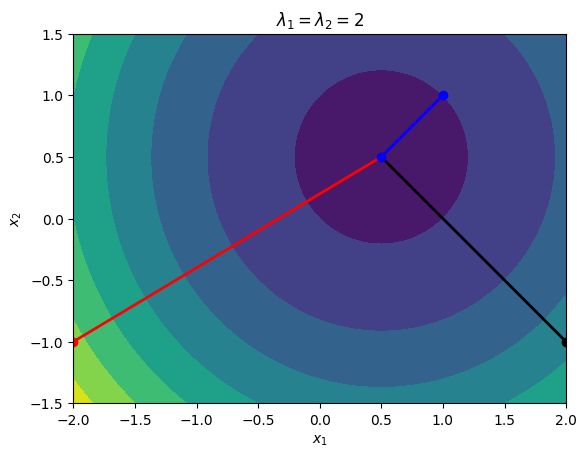

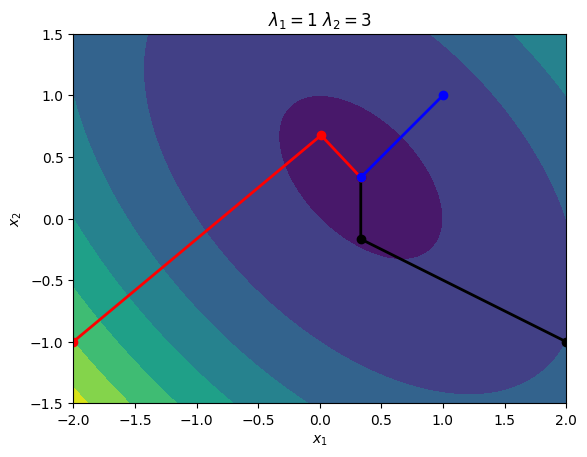

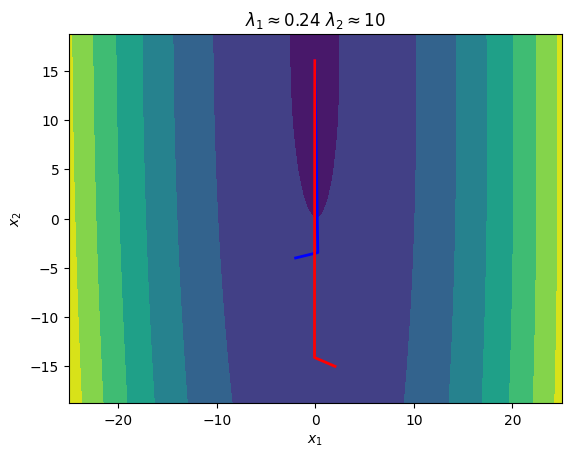

In [3]:
from line_search_library import *

def cg_quadratic(x, A, b, n=10, eps=1e-12):
    xvals = [np.array(x)]
    
    # Compute the initial gradient and step
    g = np.dot(A, x) + b
    p = -np.array(g)
    gamma = np.dot(g, g)
    
    for i in range(n):
        # Compute steps 2 - 6 of the algorithm
        t = np.dot(A, p)
        alpha = -np.dot(p, g)/np.dot(p, t)
        x = x + alpha*p
        g = g + alpha*t
        eta = np.dot(g, g)

        # Append the new design point
        xvals.append(np.array(x))

        # Check for convergence of the algorithm
        if np.sqrt(eta) < eps:
            break
        
        # Compute the new step
        beta = eta/gamma
        p = -g + beta*p
        gamma = eta
        
    return np.array(xvals)

A = np.array([[2.0, 0.0], [0.0, 2.0]])
b = np.array([-1.0, -1.0])
plot_quadratic_contour(A, b)

x0 = np.array([2.0, -1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'k-o', linewidth=2)

x0 = np.array([-2.0, -1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'r-o', linewidth=2)

x0 = np.array([1.0, 1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'b-o', linewidth=2)
plt.title('$\lambda_{1} = \lambda_{2} = 2$')

A = np.array([[2.0, 1.0], [1.0, 2.0]])
b = np.array([-1.0, -1.0])
plot_quadratic_contour(A, b)

x0 = np.array([2.0, -1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'k-o', linewidth=2)

x0 = np.array([-2.0, -1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'r-o', linewidth=2)

x0 = np.array([1.0, 1.0])
xvals = cg_quadratic(x0, A, b)
plt.plot(xvals[:,0], xvals[:,1], 'b-o', linewidth=2)
plt.title('$\lambda_{1} = 1$ $\lambda_{2} = 3$')

A = np.array([[10.0, 0.1], [0.1, 0.25]])
b = np.array([-1.0, -4.0])
plot_quadratic_contour(A, b, xdim=25)

x0 = np.array([-2.0, -4.0])
xvals = cg_quadratic(x0, A, b, n=100)
plt.plot(xvals[:,0], xvals[:,1], 'b-', linewidth=2)

x0 = np.array([2.0, -15.0])
xvals = cg_quadratic(x0, A, b, n=100)
plt.plot(xvals[:,0], xvals[:,1], 'r-', linewidth=2)

plt.title('$\lambda_{1} \\approx 0.24$ $\lambda_{2} \\approx 10$')
plt.show()

### Understanding the Conjugate Gradient Method

Conjugacy or $A$-orthogonality is defined such that for a matrix $A$ the directions $p_{i} \in \mathbb{R}^{n}$ for $i = 1,\ldots,n$ satisfy 

\begin{equation*}
p_{i}^{T} A p_{j} = 0 \qquad\qquad \text{if} \;\; i \ne j
\end{equation*}

As a result, a set of $n$ conjugate directions forms a basis for $\mathbb{R}^{n}$.

Imagine that we have precomputed the conjugate directions $\{p_{i}\}_{i=1}^{n}$ and can arrange them into a matrix $P$

\begin{equation*}
P = \begin{bmatrix} p_1 & p_2 & \ldots & p_{n} \end{bmatrix}
\end{equation*}

Set the initial point $x = 0$, and write the solution as follows:
\begin{equation*}
x = P \hat{x}
\end{equation*}

Minimize the function

\begin{equation*}
\begin{aligned}
f(x) &= \frac{1}{2} x^{T}Ax + x^{T} b  \\
&= \frac{1}{2} \hat{x}^{T}P^{T}AP \hat{x} + \hat{x}^{T}P^{T}b \\
\end{aligned}
\end{equation*}

Since $p_{i}$ are conjugate, $P^{T}AP$ is where the diagonal entries are

\begin{equation*}
P^{T}AP = \text{diag}\{ p_{1}^{T} A p_1,\; p_{2}^{T}Ap_{2},\ldots,\; p_{n}^{T}Ap_{n}\}
\end{equation*}

We can minimize the function by minimizing along each direction $p_{i}$ independently, therefore CG applied to a quadratic function converges in at most $n$ steps.

In [4]:
"""
This code demonstrates the construction of a conjugate space P
such that:

P^{T}*A*P = I

This subspace is constructed via Gram-Schmidt orthogonalization 
with respect to the A-inner product.

<x, y> = y^{T} A x

https://en.wikipedia.org/wiki/Gram%E2%80%93Schmidt_process
"""
n = 15 # Dimension of the matrix that will be generated

# Generate a random positive definite matrix with specified eigenspectrum
B = -1.0 + 2*np.random.uniform(size=(n, n))
Q, r = np.linalg.qr(B, mode='complete') # Construct Q
lam = np.linspace(1, n, n) # Create a uniform set of eigenvalues
A = np.dot(Q, np.dot(np.diag(lam), Q.T)) # Compute A = Q*Lambda*Q^{T}

def inner(A, pi, pj):
    return np.dot(pi, np.dot(A, pj))

# Compute the space P
P = np.zeros((n, n))

# Create a random vector and 
P[:,0] = np.random.uniform(size=n)
P[:,0] = P[:,0]/np.sqrt(inner(A, P[:,0], P[:,0]))

# Apply the modified Gram-Schmidt algorithm to create a conjugate
# vector space spanned by the directions P
for i in range(1, n):
    # Compute the new vector P[:,i] = A*P[:,i-1]
    P[:,i] = np.dot(A, P[:,i-1])
    
    # Compute the A-orthogonal subspace
    for j in range(i, -1, -1):
        P[:,i] = P[:,i] - P[:,j]*inner(A, P[:,i], P[:,j])
    
    # Normalize the step
    P[:,i] = P[:,i]/np.sqrt(inner(A, P[:,i], P[:,i]))
    
PtAP = np.dot(P.T, np.dot(A, P))
error = PtAP - np.eye(n)
print('Error in the conjugate space ', np.sqrt(np.sum(error**2)))

Error in the conjugate space  1.0723802510260132e-14


### Convergence Behavior of Conjugate Gradient Algorithm

Similar to the steepest descent method, the performance of the conjugate gradient method can be characterized using the condition number $\kappa(A)$.
For the conjugate gradient method, the error relationship is

\begin{equation*}
||e_{k}||_{A} \le \left(\frac{\sqrt{\kappa(A)} - 1}{\sqrt{\kappa(A)}+1}\right)^{k}||e_{1}||_{A}
\end{equation*}

This error relationship depends on the square root of the condition number and therefore is less sensitive to poorly conditioned problems.

### Conjugate Gradient Algorithm Applied to Nonlinear Functions

One of the challenges in the conjugate gradient method is selecting the initial step length.
Often a choice such as

\begin{equation*}
\alpha_{\text{new}} = \alpha_{\text{old}} \dfrac{\nabla f(x_{\text{old}})^{T} p_{\text{old}}}{\nabla f(x_{\text{new}})^{T}p_{\text{new}}}
\end{equation*}

can improve performance. But this is problem dependent.

The nonlinear Fletcher--Reeves conjugate gradient method does not use exact line searches.
To assess the consequences of this, take inner product of $p = - \nabla f(x) + \beta p_{\text{prev}}$, and the gradient:

\begin{equation*}
\nabla f(x)^{T}p = - ||\nabla f(x)||_{2}^{2} + \beta \nabla f(x)^{T} p_{\text{prev}} 
\end{equation*}
 
If we used an exact line search, $\nabla f(x)^{T} p_{\text{prev}}$ would be zero.
However, we use an inexact line search, so this term may dominate and we might have $\nabla f(x)^{T}p \ge 0$ so that $p$ is not a descent direction!
If the line search satisfies the strong Wolfe conditions then

\begin{equation*}
|\nabla f(x)^{T} p_{\text{prev}}| \le c_{2} |\nabla f(x_{\text{prev}})^{T} p_{\text{prev}}|
\end{equation*}

Nocedal and Wright show by induction that if $c_{2} < 1/2$, then the search directions generated using Fletcher--Reeves will be descent directions

Conjugate gradient method found a first-order point in 61 iterations

x =  [0.99999976 0.99999953]
grad(x) =  [-5.59153536e-07  4.43176607e-08]


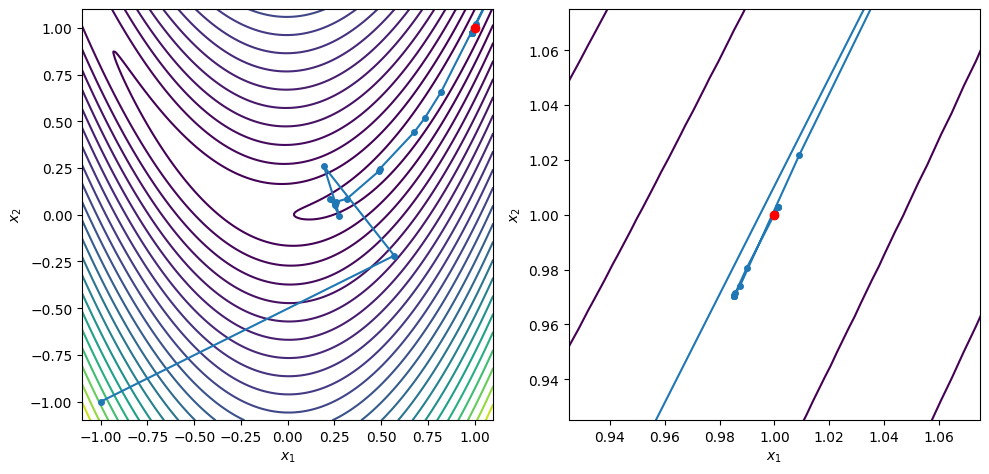

In [5]:
from line_search_library import *

def conjugate_gradient(x0, func, grad_func, 
                       c1=1e-3, c2=0.9, eps=1e-6, 
                       max_iters=2500, line_search_type='strong Wolfe'):
    """
    Solve an unconstrained optimization problem using the Fletcher-Reeves 
    conjugate gradient method
    
    input:
    x0:         the starting point
    func:       a function pointer to f(x)
    grad_func:  a function pointer to the gradient of f(x) 
    c1:         sufficient decrease parameter
    c2:         curvature condition parameter
    eps:        stopping tolerance such that ||grad f(x)|| < eps
    max_iters:  maximum number of iterations before we give up
    """
    # Make sure we are using a np array
    x = np.array(x0)
    grad_prev = np.zeros(x.shape)
    p_prev = np.zeros(x.shape)
    
    xvals = []
    
    for i in range(max_iters):
        grad = grad_func(x)
        xvals.append(np.array(x))
        
        # Check the norm of the gradient
        if np.sqrt(np.dot(grad, grad)) < eps:
            print('Conjugate gradient method found a first-order point in %d iterations\n'%(i))
            return x, np.array(xvals)
            
        if i > 0:
            beta = np.dot(grad, grad)/np.dot(grad_prev, grad_prev)
            pk = -grad + beta*p_prev
        else:
            pk = -grad
            
        # Check if we have a descent direction. If not revert to the
        # steepest descent method.
        if np.dot(pk, grad) >= 0.0:
            pk = -grad

        if line_search_type == 'strong Wolfe':
            alpha = strong_wolfe(func, grad_func, x, pk, c1=c1, c2=c2)
        else:
            alpha = backtrack(func, grad_func, x, pk, c1=c1)
        x += alpha*pk
        
        # Save the previous information
        grad_prev[:] = grad[:]
        p_prev[:] = pk[:]
    
    print('Conjugate gradient method failed to converge after %d iterations\n'%(max_iters))
    return x, np.array(xvals)

x0 = [-1.0, -1.0]
xstar, xvals = conjugate_gradient(x0, rosen, rosen_grad, c2=0.5, max_iters=100)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()

## Newton's Method

Newton's method is an alternative to conjugate gradient methods. It should be fast, since the method is quadratically convergent.
To derive the Newton update formula, consider that we have $n$ nonlinear equations, $\nabla f(x) = 0$, in the $n$ unknown design variables $x$.
Applying Newton's method, we get the formula for the step $p$

\begin{equation*}
H(x) p = - \nabla f(x)
\end{equation*}

However, we must ensure that $p$ is a descent direction. Take the dot product of both sides with $p$ to get

\begin{equation*}
p^{T}\nabla f(x) = - p^{T}H(x)p
\end{equation*}

Therefore, we are only guaranteed a descent direction if $H(x_{k})$ is positive definite.
But, $H(x)$ may be indefinite or singular at certain points in the design space, but we may still have a local minimizer somewhere else.

### Modified Newton methods

Modified Newton methods modify $H$ so that instead of a true Newton method, have:

\begin{equation*}
B p = -\nabla f(x)
\end{equation*}

Where $B$ is a modified Hessian.
Different modifications are possible: For instance, making sure
    that we have a positive definite matrix by setting $B = H(x) + \beta I$, where $\beta$ is chosen so that $B$ is positive definite. In practice, this modification can be expensive to compute
Modified Newton methods do not modify $H$ when we get close enough to $x_{k} \rightarrow x^{*}$, since $H(x^{*}) > 0$. This is important so that we recapture quadratic convergence


Modified Newton method found a first-order point in 20 iterations

x =  [0.99999998 0.99999995]
grad(x) =  [ 6.97865434e-07 -3.73021436e-07]


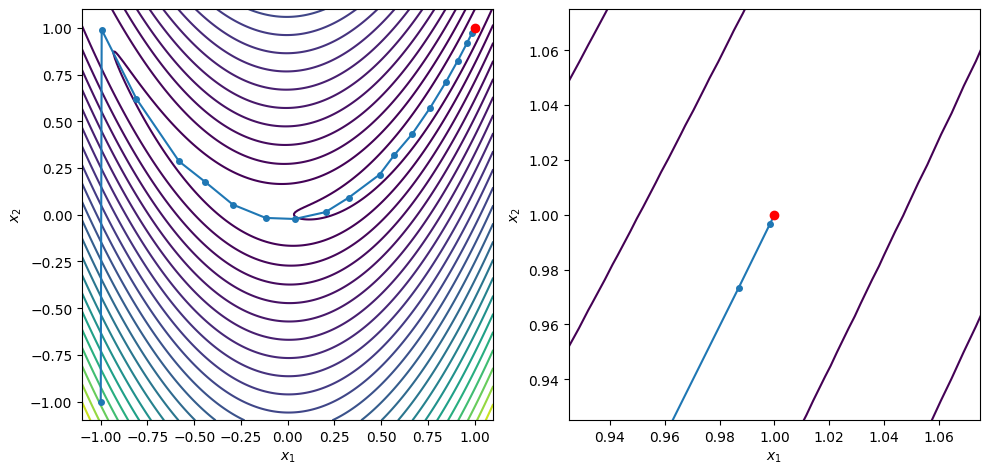

In [6]:
from line_search_library import *

def modified_newton(x0, func, grad_func, hessian_func,
                    c1=1e-3, c2=0.9, eps=1e-6, 
                    max_iters=2500, line_search_type='strong Wolfe'):
    """
    Solve an unconstrained optimization problem using a modified Newton
    method
    
    input:
    x0:         the starting point
    func:       a function pointer to f(x)
    grad_func:  a function pointer to the gradient of f(x) 
    c1:         sufficient decrease parameter
    c2:         curvature condition parameter
    eps:        stopping tolerance such that ||grad f(x)|| < eps
    max_iters:  maximum number of iterations before we give up
    """
    # Make sure we are using a np array
    x = np.array(x0)
    
    xvals = []
    
    for i in range(max_iters):
        grad = grad_func(x)
        H = hessian_func(x)
        xvals.append(np.array(x))
        
        # Check the norm of the gradient
        if np.sqrt(np.dot(grad, grad)) < eps:
            print('Modified Newton method found a first-order point in %d iterations\n'%(i))
            return x, np.array(xvals)
        

        # Compute the eigenvalues and eigenvectors
        lam, Q = np.linalg.eigh(H)

        # If the smallest eigenvalue is negative, modify the Hessian to be positive definite
        if lam[0] < 0.01:
            beta = np.fabs(lam[0]) + 0.01*np.fabs(lam[-1])
            B = H + beta * np.eye(len(x))
            p = -np.linalg.solve(B, grad)
        else:
            # Otherwise, compute the exact Newton step
            p = -np.linalg.solve(H, grad)
                        
        # Check if we have a descent direction. If not revert to the
        # steepest descent method.
        if np.dot(p, grad) >= 0.0:
            p = -grad

        if line_search_type == 'strong Wolfe':
            alpha = strong_wolfe(func, grad_func, x, p, c1=c1, c2=c2)
        else:
            alpha = backtrack(func, grad_func, x, p, c1=c1)
        x += alpha*p
    
    print('Modified Newton method failed to converge after %d iterations\n'%(max_iters))
    return x, np.array(xvals)


def rosen_hess(x):
    return np.array([[1200*x[0]**2 - 400*x[1] + 2.0, -400*x[0]],
                     [-400*x[0], 200]])

x0 = [-1.0, -1.0]
xstar, xvals = modified_newton(x0, rosen, rosen_grad, rosen_hess, c2=0.5, max_iters=100)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()

## Quasi-Newton Methods

Quasi-Newton methods are designed to incrementally approximate the Hessian matrix by adding information to an approximate Hessian at each iteration. Some methods estimate the Hessian, while other techniques are designed to estimate the inverse of the Hessian matrix.

Quasi-Newton methods enforce a secant condition that the Hessian approximation, $B_{k+1} \approx H(x)$, at the $k+1$ iteration must satisfy

\begin{equation*}
B_{k+1} s_{k} = y_{k},
\end{equation*}

where $s_{k} = x_{k+1} - x_{k}$ and $y_{k} = \nabla f_{k+1} - \nabla f_{k}$ are the differences in the design vector and gradient vector between two iterations. It can also be useful to approximate the inverse of the Hessian, since we will generally utilize the inverse Hessian to compute the update. The secant condition for the inverse Hessian approximation can be written as

\begin{equation*}
D_{k+1} y_{k} = s_{k},
\end{equation*}

where $D_{k+1} \approx H(x)^{-1}$.

In the following section the subscripts on the vectors $s_{k}$ and $y_{k}$ are omitted.

### The secant condition

How is the secant condition derived?
Consider a quadratic model of the objective function

\begin{equation*}
m_{k}(p) = f(x) + \nabla f^{T}(x) p + \frac{1}{2} p^{T} B_{k} p
\end{equation*}

Here the model $m_{k}(p)$ is updated at each iteration by evaluating the function and gradient at the new point $x$ and obtaining new expressions for the quadratic terms $B_{k}$.
As in all our examples, $B_{k} = B_{k}^{T}$.

When we take a step to $x + s$, (here $s = \alpha p$, where $p$ is our line search step multiplied by the step length $\alpha$) the new model will become

\begin{equation*}
m_{k+1}(p) = f(x + s) + \nabla f^{T}(x + s) p + \frac{1}{2} p^{T} B_{k+1} p
\end{equation*}

We derive the secant conidition so that the gradient of the model function matches the true function gradient at both $x$ and $x + s$.
The gradient of the model is

\begin{equation*}
\nabla m_{k+1} = \nabla f(x + s) + B_{k+1} p
\end{equation*}

Using the model $m_{k+1}$, we look back at our previous point and enforce that the gradient of $m_{k+1}$ at $p = -s$ should be equal to $\nabla f(x)$ so that

\begin{equation*}
\nabla m_{k+1}(-s) = \nabla f(x + s) - B_{k+1} s = \nabla f(x)
\end{equation*}

As a result, the secant condition is

\begin{equation*}
B_{k+1} s = \nabla f(x + s) - \nabla f(x) = y
\end{equation*}

### The curvature condition

Often, we're interested in maintaining a positive definite approximation of the Hessian.
To do so, we'll require a curvature condition for the step $s$ and gradient difference $y$

\begin{equation*}
s^{T} B_{k+1} s = s^{T} y > 0
\end{equation*}

The curvature condition is satisfied automatically when we use steps computed using the strong Wolfe conditions
To observe this, consider

\begin{equation*}
\begin{aligned}
s^{T} y 
&= \alpha p^{T} (\nabla f(x + s) - \nabla f(x)) \\
&= \alpha (p^{T} \nabla f(x + \alpha p) - p^{T} \nabla f(x)) \\
\end{aligned}
\end{equation*}

Recall that $\phi'(0) = p^{T} \nabla f(x) < 0$, since we require a descent direction.
The second strong Wolfe condition enforces 

\begin{equation*}
|\phi'(\alpha)| = |\nabla f(x + \alpha p)^{T} p| < - c_{2} \phi'(0) = - c_{2} p^{T} \nabla f(x)
\end{equation*}

As a result, when the strong Wolfe conditions are satisfied

\begin{equation*}
s^{T} y \ge \alpha (c_{2} - 1) \nabla f(x)^{T} p > 0 
\end{equation*}
  
In practice, quasi-Newton methods, and BFGS in particular, work well in conjunction with the strong Wolfe line search conditions.

### Deriving the BFGS formula

The secant condition $B_{k+1} s = y$ alone does not determine the update formula uniquely.
Instead, quasi-Newton update formula can be found by solving the following constrained optimization problem:

\begin{equation*}
\begin{aligned}
\min_{B} \qquad & ||B - B_{k}||_{F} \\
\text{such that} \qquad & B = B^{T} \\
& B s = y
\end{aligned}
\end{equation*}

Here $||\cdot||_{F}$ is the Frobenius norm $||A||_{F} = \sum_{i,j} A_{ij}^{2}$.
Different quasi-Newton methods can be found by minimizing the difference between $B_{k}$ and $B_{k+1}$, or $B_{k}^{-1}$ and $B_{k+1}^{-1}$ or changing the norm.

A more direct derivation of the BFGS method is presented below.
Consider that the update must only use information from $s$, $y$, and $B$.
Since the update must be symmetric and must satisfy the condition $B_{k+1} s = y$, one reasonable guess for the expected update is

\begin{equation*}
B_{k+1} = B_{k} + b_{1} s s^{T} + b_{2} y y^{T} + b_{3} B_{k} s s^{T} B_{k} + b_{4} B_{k} y y^{T} B_{k}
\end{equation*}

Multiplying through by $s$ for the secant condition gives

\begin{equation*}
B_{k+1}s = B_{k}s + b_{1} s s^{T}s + b_{2} y y^{T}s + b_{3} B_{k} s s^{T} B_{k}s + b_{4} B_{k} y y^{T} B_{k}s
\end{equation*}

In general, $s$, $y$, $B_{k} s$ and $B_{k}y$ are linearly independent vectors.
Since we have to have that $B_{k+1} s = y$, that means that $b_{1} = 0$ and $b_{4} = 0$.
Collecting the remaining terms gives

\begin{equation*}
B_{k+1}s = b_{2} y y^{T}s + B_{k}s(1 + b_{3} s^{T} B_{k}s)
\end{equation*}

We can immediately see that $b_{2} = 1/y^{T}s$ and $b_{3} = 1/s^{T} B_{k}s$. This gives the formula

\begin{equation*}
B_{k+1} = B_{k} - \dfrac{Bs s^T B}{s^{T}B s} + \dfrac{yy^T}{y^{T} s}
\end{equation*}

The update for the inverse of the BFGS method can be found via the Sherman-Morrison-Woodburry formula.


### BFGS

The BFGS update formula relies on the curvature condition $y^{T} s > 0$ to ensure that the Hessian approximation remains positive definite.
A positive definite Hessian approximation ensures that the descent direction:

\begin{equation*}
p = - B_{k}^{-1} \nabla f(x)
\end{equation*}

is a descent direction since we have $p^{T} \nabla f(x) = p^{T}Bp$.

The BFGS update formula for the Hessian approximation is given by

\begin{equation*}
B_{k+1} = B_{k} - \frac{B_{k} s\, s^{T} B_{k}}{s^{T} B_{k} s} + \rho y y^{T},
\end{equation*}

where $\rho = (y^{T} s)^{-1}$. Here the subscripts on the $y$ and $s$ vectors have been removed.

The inverse Hessian update formula is given by 

\begin{equation*}
D_{k+1} = (I - \rho s y^{T}) D_{k} (I - \rho y s^{T}) + \rho s s^{T}.
\end{equation*}

While there are different families of rank-2 update formula for quasi-Newton methods that can be applied (the Broyden class for instance), BFGS is the most common. This is due to the mathematical properties of the BFGS method that enable it to recover from a poor initial guess. These properties have been verified based on extensive analysis and numerical testing.

### SR-1 (Symmetric rank-1 update)

Another common quasi-Newton method is the SR1 formula: the symmetric rank-1 update. This update can be found as follows

Consider the update:

\begin{equation*}
B_{k+1} = B_{k} + b_{1} (y - B_{k} s)(y - B_{k} s)^{T}
\end{equation*}

Using the secant condition gives

\begin{equation*}
B_{k+1} s = B_{k} s + b_{1} (y - B_{k} s)(y - B_{k} s)^{T}s = y
\end{equation*}

Collecting the terms gives

\begin{equation*}
(B_{k} s - y)(1 - b_{1}(y - B_{k} s)^{T}s) = 0
\end{equation*}

So we must have that $b_{1} = 1/(y - B_{k} s)^{T}s$. This gives the following formula for the SR-1 update

\begin{equation*}
B_{k+1} = B_{k} + \frac{(y - B_{k} s)(y - B_{k} s)^{T}}{(y - B_{k} s)^T s}
\end{equation*}

The update for the inverse of the SR-1 method can be found via the Sherman-Morrison-Woodburry formula as follows, given an invertible $A$ and the vector $v$, then

\begin{equation*}
(A + \beta vv^{T})^{-1} = A^{-1} - \beta \dfrac{A^{-1}v v^{T} A^{-1}}{1 +\beta  v^{T}A^{-1} v}
\end{equation*}

The update to the inverse of the Hessian can be written as

\begin{equation*}
D_{k+1} = D_{k} + \frac{(s - D_{k} y)(s - D_{k}y)^{T}}{(s - D_{k}y)^{T}y}
\end{equation*}

Note that the update for the inverse Hessian can be obtained from the update for the Hessian by swapping $B_{k}$ with $D_{k}$, and switching $y$ for $s$ and $s$ for $y$.

### Example

In this example, we explore the performance of the BFGS and SR-1 method on quadratic functions

\begin{equation*}
f(x) = \frac{1}{2}x^{T} A x + b^{T}x
\end{equation*}

where $A$ is symmetric positive definite. In practice, we will also utilize an inexact line search method, but in this instance, we can use exact line searches.

In this example, we look at the error in the eigenvalues of the Hessian matrix $B \approx A$ and the inverse matrix $D \approx A^{-1}$. Note that we construct the matrix $A$ with a known eigenspectra while the matrix $A^{-1}$ should have eigenvalues $1/\lambda(A)$. 

Condition number:              10.0
Final eigenvalues for B:       [ 1. 10.]
Final eigenvalues for inv(D):  [ 1. 10.]
Condition number:              10.0
Final eigenvalues for B:       [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Final eigenvalues for inv(D):  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Condition number:              999999.9999999998
Final eigenvalues for B:       [1.00000000e-03 2.75547773e-02 1.28086282e-01 3.52078947e-01
 7.49017204e-01 1.36838549e+00 2.25966822e+00 3.47234985e+00
 5.05591481e+00 7.05984751e+00 9.53363241e+00 1.25267539e+01
 1.60886965e+01 2.02689445e+01 2.51169825e+01 3.06822948e+01
 3.70143659e+01 4.41626802e+01 5.21767222e+01 6.11059763e+01
 7.09999268e+01 8.19080583e+01 9.38798552e+01 1.06964802e+02
 1.21212383e+02 1.36672082e+02 1.53393385e+02 1.71425775e+02
 1.90818738e+02 2.11621756e+02 2.33884316e+02 2.57655900e+02
 2.82985995e+02 3.09924083e+02 3.38519651e+02 3.68822181e+02
 4.00881158e+02 4.34746068e+02 4.70466394e+02 5.08091620e+02
 5.4767123

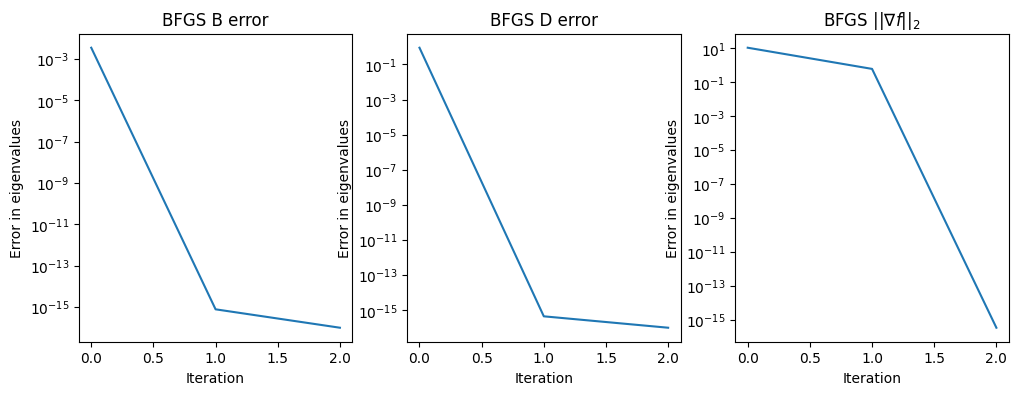

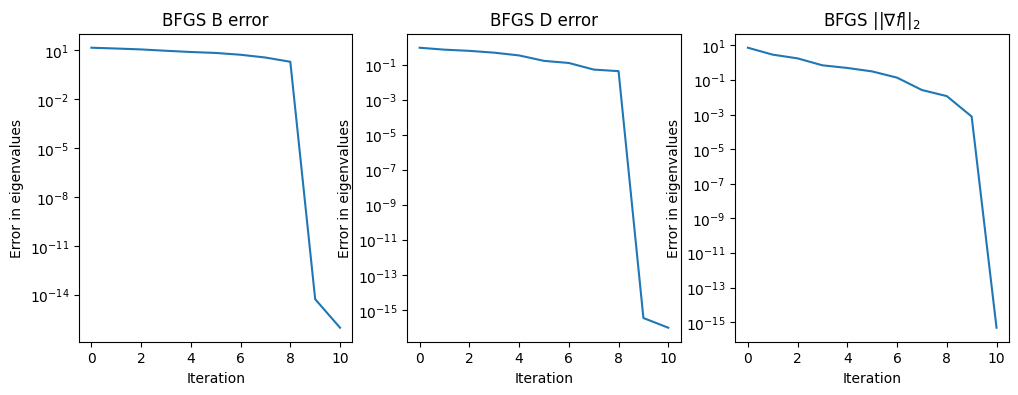

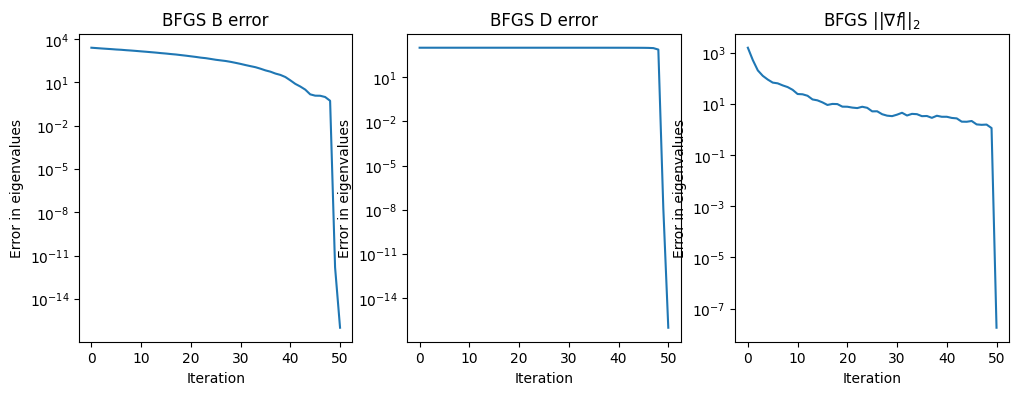

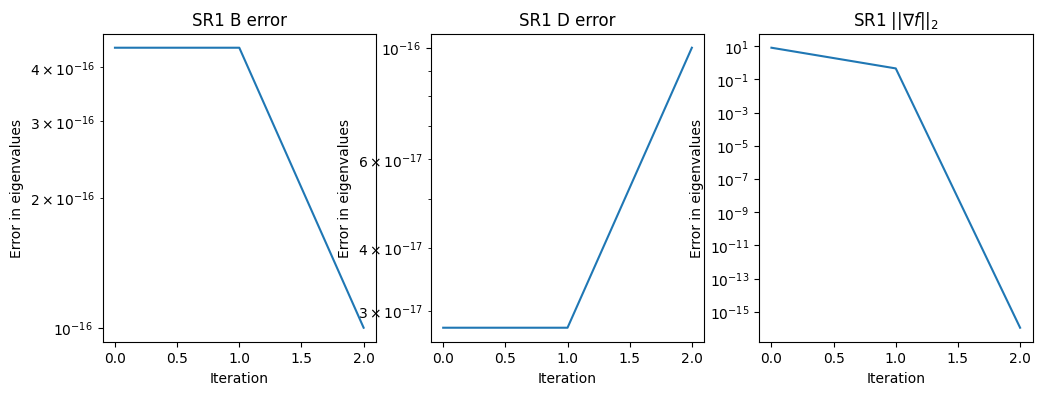

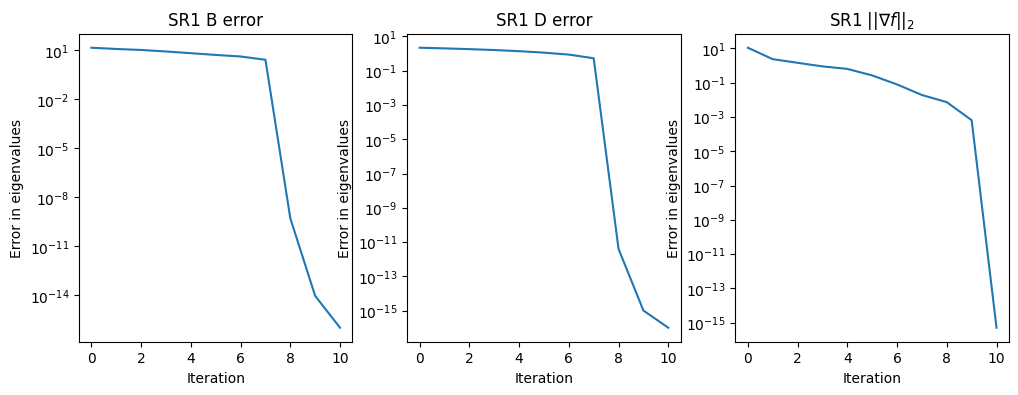

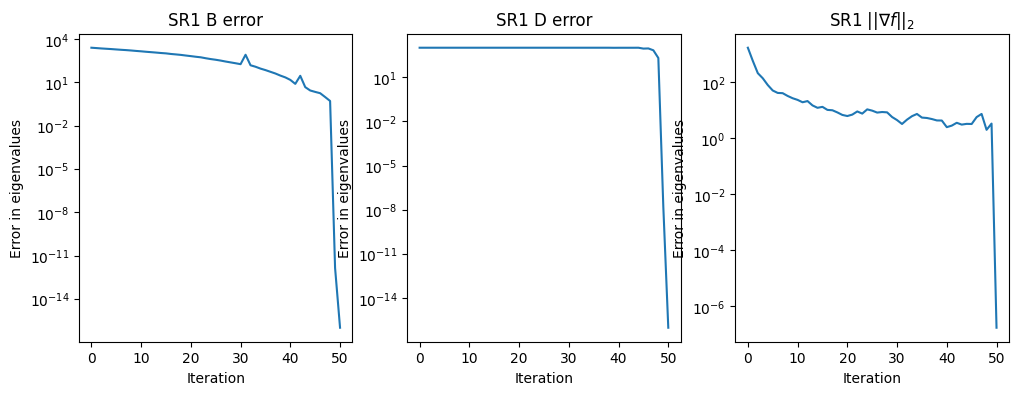

In [7]:
import numpy as np
import matplotlib.pylab as plt

def create_matrix_from_eigs(lam):
    """Generate a random matrix with the specified updates"""
    n = len(lam)
    lam = np.array(lam)
    
    B = -1.0 + 2.0*np.random.uniform(size=(n, n))
    Q, r = np.linalg.qr(B, mode='complete')
    A = np.dot(Q, np.dot(np.diag(lam), Q.T))
    
    return A

class BFGS:
    def __init__(self, n):
        self.n = n        
        self.D = None
        self.B = None
        return
    
    def update(self, s, y):
        """Perform the update"""
        
        # Check the curvature condition
        if np.dot(y, s) >= 0.0:
            # Compute the value of rho
            rho = 1.0/np.dot(y, s)

            # If we're on the initial iteration, reset the new values
            if self.D is None:
                scale = np.dot(y, s)/np.dot(y, y)
                self.D = scale*np.eye(self.n)

            # Compute the BFGS update
            W = np.eye(self.n) - rho*np.outer(y, s)
            self.D = np.dot(W.T, np.dot(self.D, W))
            self.D += rho*np.outer(s, s)
            
            if self.B is None:
                scale = np.dot(y, y)/np.dot(y, s)
                self.B = np.eye(self.n)
            
            r = np.dot(self.B, s)
            beta = 1.0/np.dot(s, r)
            self.B = self.B - beta*np.outer(r, r) + rho*np.outer(y, y)
            
        return
    
class SR1:
    def __init__(self, n, tol=1e-12):
        self.n = n        
        self.D = np.eye(self.n)
        self.B = np.eye(self.n)
        self.tol = tol
        return
    
    def update(self, s, y):
        """Perform the update"""
        
        # Update the Hessian approximation
        r = y - np.dot(self.B, s)
        beta = np.dot(r, s)
        if np.fabs(beta)/np.dot(s, s) > self.tol:
            self.B += np.outer(r, r)/beta
        
        # Update the approximate inverse Hessian
        r = s - np.dot(self.D, y)
        beta = np.dot(r, y)
        if np.fabs(beta)/np.dot(s, s) > self.tol:
            self.D += np.outer(r, r)/beta
            
        return

def test_quasi_newton(lam, qn_type='bfgs', max_iters=-1, eps=1e-6):
    """
    Test the quasi-Newton method using a quadratic 
    with exact line searches
    """
    # Set the max number of iterations (unless it is set externally)
    if max_iters < 0:
        max_iters = len(lam)+1

    # Sort the eigenvalues and convert them to a numpy array
    lam = np.array(sorted(lam))
        
    # Quit if this is not a positive definite case
    if lam[0] <= 0.0:
        print('Only works for positive definte cases')
        return
    
    # Create the matrix from the eigenvalues
    n = len(lam)
    A = create_matrix_from_eigs(lam)
    
    # Create the quadratic right-hand-side
    b = np.random.uniform(size=n)
    
    # Create the BFGS object
    qn = None
    if qn_type == 'bfgs':
        qn = BFGS(n)
    else:
        qn = SR1(n)
    
    # Set the starting point
    x = np.random.uniform(size=n)
    
    gradient_norm = np.zeros(max_iters)
    error_B = np.zeros(max_iters)
    error_D = np.zeros(max_iters)
    for i in range(max_iters):
        # Compute the function gradient
        g = np.dot(A, x) + b
        
        # Compute the l2 norm of the gradient
        gradient_norm[i] = np.sqrt(np.dot(g, g))
        
        if gradient_norm[i] < eps:
            break
        
        # Find the search direction
        if i == 0:
            p = -g
        else:
            p = -np.linalg.solve(qn.B, g)
    
        # Compute the exact line search step length
        alpha = -np.dot(p, g)/np.dot(p, np.dot(A, p))

        # Compute the step and the difference in the gradients
        s = alpha*p
        y = np.dot(A, s)
        
        # Update the value of x
        x += s
        
        # Update the quasi-Newton formula
        qn.update(s, y)
        
        # Compute the eigenvalues of the Hessian approximation
        eigs, v = np.linalg.eigh(qn.B)
                
        # Compute the error
        error_B[i] = np.sqrt(np.dot(eigs - lam, eigs - lam))

        # Compute the eigenvalues of the Hessian approximation
        eigs, v = np.linalg.eigh(qn.D)
        
        # Compute the error
        error_D[i] = np.sqrt(np.dot(eigs[::-1] - 1.0/lam,
                                    eigs[::-1] - 1.0/lam))
    
    print('Condition number:             ', lam[-1]/lam[0])
    
    eigs, v = np.linalg.eigh(qn.B)
    print('Final eigenvalues for B:      ', eigs)

    eigs, v = np.linalg.eigh(qn.D)
    print('Final eigenvalues for inv(D): ', 1.0/eigs[::-1])

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    error_B[error_B <= 0.0] = 1e-16
    ax[0].semilogy(np.arange(max_iters), error_B)
    ax[0].set_title('%s B error'%(qn_type.upper()))
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Error in eigenvalues')

    error_D[error_D <= 0.0] = 1e-16
    ax[1].semilogy(np.arange(max_iters), error_D)
    ax[1].set_title('%s D error'%(qn_type.upper()))
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Error in eigenvalues')

    ax[2].semilogy(np.arange(max_iters), gradient_norm)
    gradient_norm[gradient_norm <= 0.0] = 1e-16
    ax[2].set_title(r'%s $||\nabla f||_{2}$'%(qn_type.upper()))
    ax[2].set_xlabel('Iteration')
    ax[2].set_ylabel('Error in eigenvalues')

    return

test_quasi_newton([1, 10])
test_quasi_newton([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
test_quasi_newton(np.linspace(0.1, 10)**3)

test_quasi_newton([1, 10], qn_type='sr1')
test_quasi_newton([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], qn_type='sr1')
test_quasi_newton(np.linspace(0.1, 10)**3, qn_type='sr1')

### Considerations for quasi-Newton methods

We need to start the BFGS formula with an initial Hessian (or inverse Hessian) approximation. One approach is to perform the first line search and, before using the BFGS update to get $D_{1}$, set $D_{0}$ based on the initial curvature as follows:

\begin{equation*}
D_{0} = \frac{y_{1}^{T}s_{1}}{y_{1}^{T}y_{1}} I
\end{equation*}

The strong Wolfe condition line search ensures that the curvature condition $y^{T}s > 0$ is satisified.
If the line search is not based on the strong Wolfe conditions, then another strategy is required to ensure that the update keeps $D_{k}$ or $B_{k}$ positive definite.
There are different strategies that are used, particularly in the context of constrained optimization

1. Skip update if $y^{T}s \le 0$ or $y^{T}s \le 0.2s^{T}B_{k} s$.
2. Modify the update $s$ to ensure positive definite update  (e.g. SNOPT)
3. Perform damped update which adds an extra component to $y$ to ensure positive definite approximation

The updates to either the Hessian or inverse Hessian approximation require dense matrices. This is okay, if we have $\mathcal{O}(10^2)$ variables, but not if we have $\mathcal{O}(10^4)$.
Limited-memory quasi-Newton methods truncate the number of updates at $m$, where $m \ll n$, e.g. $m = 7$. 
The information for each update is stored in a series of vectors $y$ and $s$, and the quasi-Newton update loop is unrolled.
Limited-memory reduce effectiveness of the BFGS updating  somewhat: generally from super-linear convergence to linear convergence in theory.
However, limited-memory schemes are essential for large optimization problems.

BFGS method found a first-order point in 24 iterations

x =  [1. 1.]
grad(x) =  [-1.37900922e-08  6.69615474e-09]


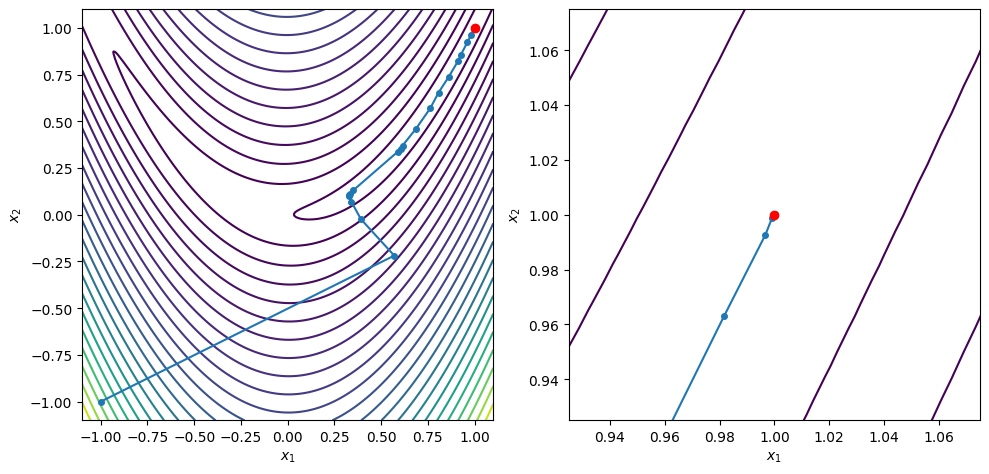

In [8]:
def bfgs_line_search(x0, func, grad_func,
                     c1=1e-3, c2=0.9, eps=1e-6,
                     max_iters=2500):
    """
    Solve an unconstrained optimization problem using the BFGS
    method with a line search.

    input:
    x0:         the starting point
    func:       a function pointer to f(x)
    grad_func:  a function pointer to the gradient of f(x)
    c1:         sufficient decrease parameter
    c2:         curvature condition parameter
    eps:        stopping tolerance such that ||grad f(x)|| < eps
    max_iters:  maximum number of iterations before we give up
    """
    # Make sure we are using a np array
    x = np.array(x0)

    # Store the list of values
    xvals = []
    
    # Allocate the quasi-Newton object that will store
    # the quasi-Newton Hessian approximation
    qn = BFGS(len(x))

    # Store the gradient
    grad = grad_func(x)
    
    for i in range(max_iters):
        xvals.append(np.array(x))

        # Check the norm of the gradient
        if np.sqrt(np.dot(grad, grad)) < eps:
            print('BFGS method found a first-order point in %d iterations\n'%(i))
            return x, np.array(xvals)

        if qn.D is not None:
            p = -np.dot(qn.D, grad)
        else:
            p = -grad
            
        # Check if we have a descent direction. If not revert to the
        # steepest descent method.
        if np.dot(p, grad) >= 0.0:
            p = -grad

        # Perform a strong Wolfe condition line search
        alpha = strong_wolfe(func, grad_func, x, p, c1=c1, c2=c2)
            
        # Step to the new point
        x += alpha*p
        
        # Evaluate the gradient at the new point
        t = grad_func(x)

        # Perform the quasi-Newton update
        s = alpha*p
        y = t - grad
        qn.update(s, y)
        
        # Set the gradient at the new point
        grad[:] = t

    print('BFGS method failed to converge after %d iterations\n'%(max_iters))
    return x, np.array(xvals)

x0 = [-1.0, -1.0]
xstar, xvals = bfgs_line_search(x0, rosen, rosen_grad, c2=0.9, max_iters=100)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()

BFGS method found a first-order point in 9 iterations

x =  [ 0.70710682 -0.20710688]
grad(x) =  [ 2.21126411e-08 -1.24165861e-07]
BFGS method found a first-order point in 7 iterations

x =  [-0.70710678 -0.70710678]
grad(x) =  [ 1.51645738e-08 -1.11472402e-08]
BFGS method found a first-order point in 8 iterations

x =  [ 0.70710699 -0.70710682]
grad(x) =  [ 8.30543806e-07 -1.63716530e-07]
BFGS method found a first-order point in 7 iterations

x =  [ 0.70710681 -0.70710679]
grad(x) =  [ 9.83893851e-08 -4.57964942e-08]
BFGS method found a first-order point in 7 iterations

x =  [0.70710678 0.70710679]
grad(x) =  [-5.56507085e-09  2.36019182e-08]


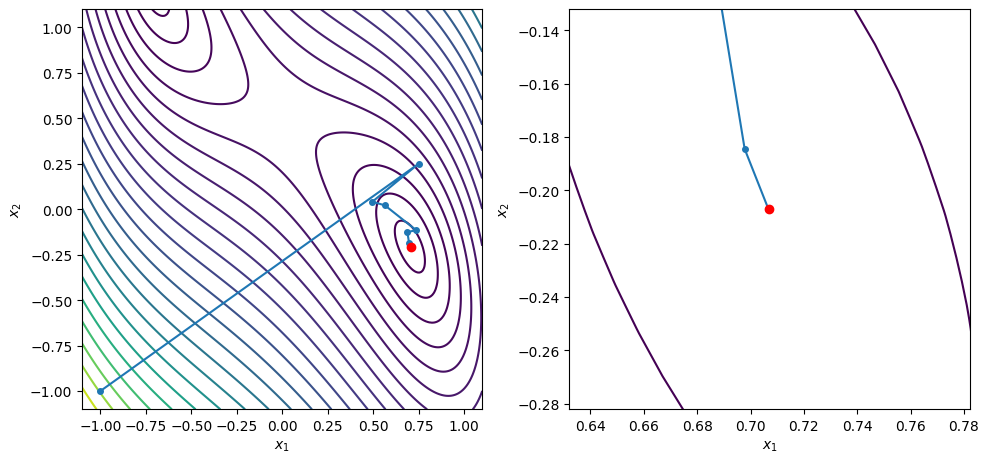

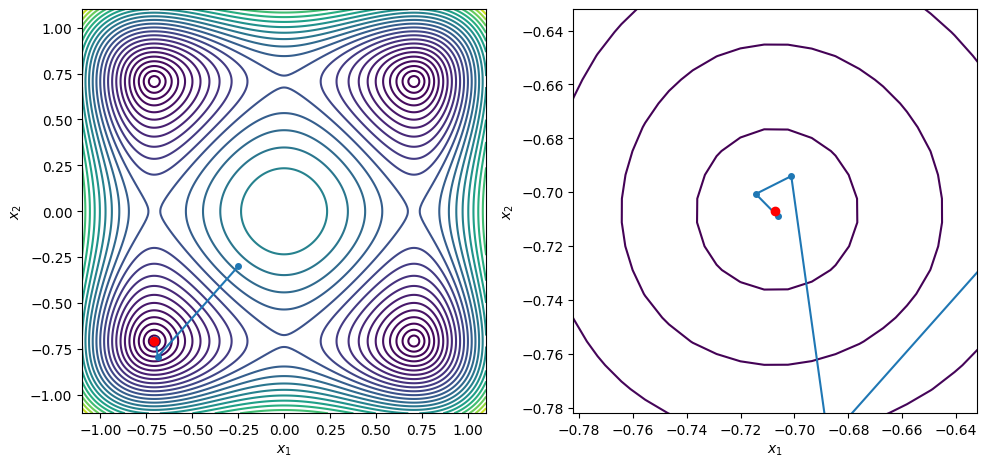

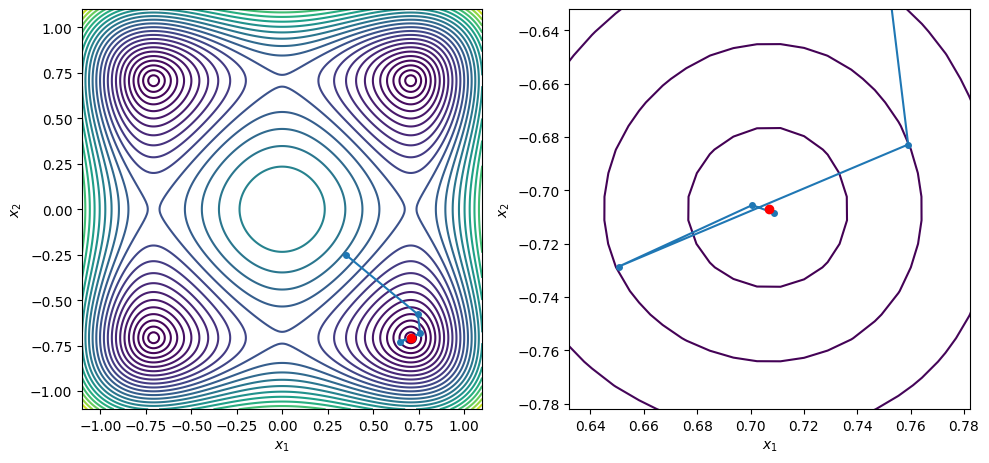

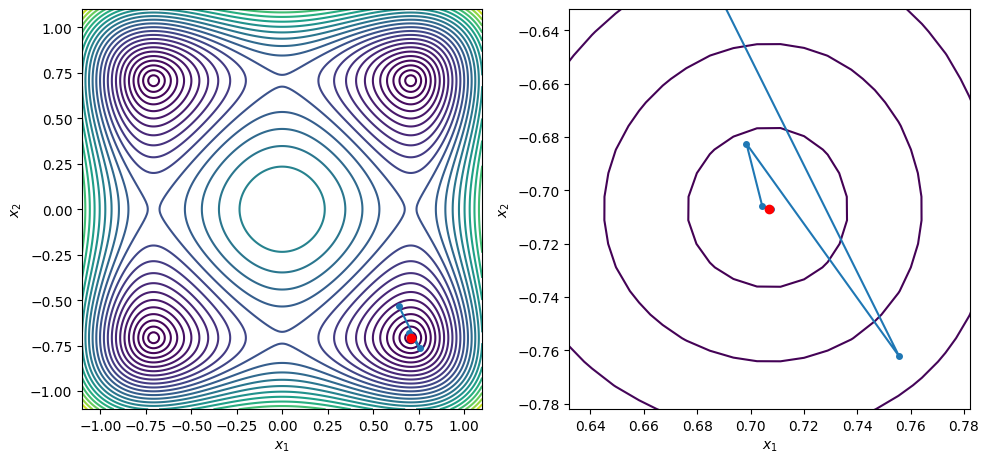

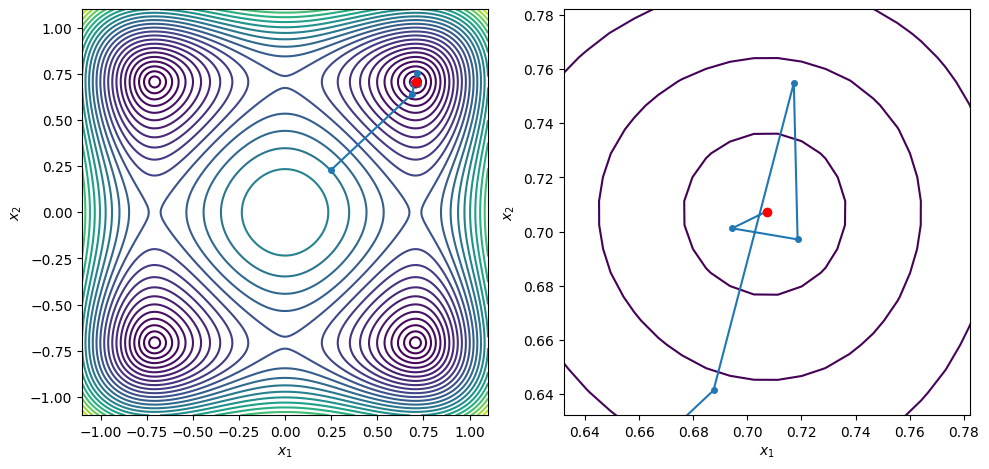

In [9]:
def f1(x):
    return x[0]**4 + x[1]**2 + 2*x[0]*x[1] - x[0] - x[1]
    
def g1(x):
    return np.array([4*x[0]**3 + 2*x[1] - 1.0,
                     2*x[1] + 2*x[0] - 1.0])

def f2(x):
    return x[0]**4 + x[1]**4 + 1 - x[0]**2 - x[1]**2

def g2(x):
    return np.array([4*x[0]**3 - 2*x[0], 4*x[1]**3 - 2*x[1]])

x0 = [-1.0, -1.0]
xstar, xvals = bfgs_line_search(x0, f1, g1, c2=0.9, max_iters=100)
contour_plot_function(f1, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', g1(xstar))

points = [[-0.25, -0.3], [0.35, -0.25], [0.64, -0.53], [0.25, 0.23]]
for x0 in points:
    xstar, xvals = bfgs_line_search(x0, f2, g2, c2=0.9, max_iters=100)
    contour_plot_function(f2, xvals, xstar)
    print('x = ', xstar)
    print('grad(x) = ', g2(xstar))

plt.show()